In [62]:
# import libraries

import numpy as np
import pandas as pd
import geopandas as gpd

import json

import matplotlib.pyplot as plt

import leafmap.maplibregl as leafmap

import os

Import files

In [63]:
# Load total pop
total_pop_folder = "Population Data"
pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_age_breakdown.parquet"))

# Load student pop
student_pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_stu_breakdown.parquet"))

# Load school pop
school_folder = "School Data"
school_gdf = gpd.read_parquet(os.path.join(school_folder, "swk_list_of_schools_2025.parquet"))

# Load combined routes
routes_folder = "OSRM Routes to Nearest School"
secondary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "secondary_combined_routes.parquet"))
primary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "primary_combined_routes.parquet"))

# Load aggregated data
aggregated_data_folder = "Aggregated Data"
district_time_stats_df = pd.read_csv(os.path.join(aggregated_data_folder,"district_summary_statistics_time_min.csv"))

# Boundaries
boundary_folder = "Geographic Boundaries"
swk_districts_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_districts.geojson")) # District boundaries
swk_parlimen_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_parliament.geojson")) # Parlimen boundaries
swk_dun_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_dun.geojson")) # DUN boundaries

In [64]:
# Create total, primary and secondary population gdfs
total_pop_gdf = pop_gdf.copy()[["id","total_pop","x","y","geometry"]]
primary_pop_gdf = student_pop_gdf.copy()[["id","primary_school_students","x","y","geometry"]]
secondary_pop_gdf = student_pop_gdf.copy()[["id","secondary_school_students","x","y","geometry"]]

# Round numbders
total_pop_gdf["total_pop"] = total_pop_gdf["total_pop"].round(0).astype(int)
primary_pop_gdf["primary_school_students"] = primary_pop_gdf["primary_school_students"].round(0).astype(int)
secondary_pop_gdf["secondary_school_students"] = secondary_pop_gdf["secondary_school_students"].round(0).astype(int)

# Rename columns
total_pop_gdf = total_pop_gdf.rename(columns={"id":"pop_id","total_pop":"total_population"})
primary_pop_gdf = primary_pop_gdf.rename(columns={"id":"pop_id"})
secondary_pop_gdf = secondary_pop_gdf.rename(columns={"id":"pop_id"})

In [65]:
# Create primary and school gdf
primary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Primary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]
secondary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Secondary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]

# Rename columns
primary_school_gdf = primary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})
secondary_school_gdf = secondary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})

In [66]:
# Clean routes data
def clean_combined_routes_gdf(combined_routes_gdf):
    # Remove columns
    combined_routes_gdf = combined_routes_gdf.drop(columns=["euclidean_km"])
    
    # Rename columns
    combined_routes_gdf = combined_routes_gdf.rename(columns={
        "combined_route": "travel_mode",
        "osrm_km": "dist_km",
        "osrm_min": "time_min"
    })
    
    # Round numbers
    combined_routes_gdf["dist_km"] = combined_routes_gdf["dist_km"].round(1)
    combined_routes_gdf["time_min"] = combined_routes_gdf["time_min"].round(0)
    return combined_routes_gdf

secondary_combined_routes_gdf = clean_combined_routes_gdf(secondary_combined_routes_gdf)
primary_combined_routes_gdf = clean_combined_routes_gdf(primary_combined_routes_gdf)

In [67]:
# merge population gdf with combined routes gdf
secondary_pop_routes_gdf = secondary_pop_gdf[["pop_id","secondary_school_students"]].merge(
    secondary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

primary_pop_routes_gdf = primary_pop_gdf[["pop_id","primary_school_students"]].merge(
    primary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

Output folder maps

In [68]:
output_folder_maps = "Interactive Maps"

Find the share of travel time in each bucket

In [69]:
# First, create new category column

# If time_min < 30, let "Travel Time" = "< 30 mins"
# If time_min 30-60, let "Travel time" = "30 to 60 mins"
# If time_min 60-90, let "Travel time" = "60 to 90 mins"
# If time_min > 90, let "Travel time" = "> 90 mins"
# If na, then "Travel time" = "No Route"

def categorise_travel_time(gdf):
    gdf["Travel Time"] = pd.cut(
        gdf["time_min"],
        bins=[-1, 30, 60, 90, float("inf")],
        labels=["< 30 mins", "30 to 60 mins", "60 to 90 mins", "> 90 mins"]
    )

    # Replace NaN with "No Route"
    gdf["Travel Time"] = gdf["Travel Time"].cat.add_categories("No Route")
    gdf["Travel Time"] = gdf["Travel Time"].fillna("No Route")
    
    return gdf

secondary_pop_routes_gdf = categorise_travel_time(secondary_pop_routes_gdf)
primary_pop_routes_gdf = categorise_travel_time(primary_pop_routes_gdf)


In [70]:
# Use pivot table to create categorisation
secondary_time_pt = secondary_pop_routes_gdf.pivot_table(
    index="Travel Time",
    values="secondary_school_students",
    aggfunc = "sum"
)

primary_time_pt = primary_pop_routes_gdf.pivot_table(
    index="Travel Time",
    values="primary_school_students",
    aggfunc="sum"
)

# Merged tables
merged_time_pt = primary_time_pt.merge(secondary_time_pt, on="Travel Time", how="outer")

In [71]:
# Now, calculate percentages
primary_total = merged_time_pt["primary_school_students"].sum()
secondary_total = merged_time_pt["secondary_school_students"].sum()

# Calculate percentages
merged_time_pt["primary_pct"] = (
    merged_time_pt["primary_school_students"] / primary_total * 100
)

merged_time_pt["secondary_pct"] = (
    merged_time_pt["secondary_school_students"] / secondary_total * 100
)

Create donut chart

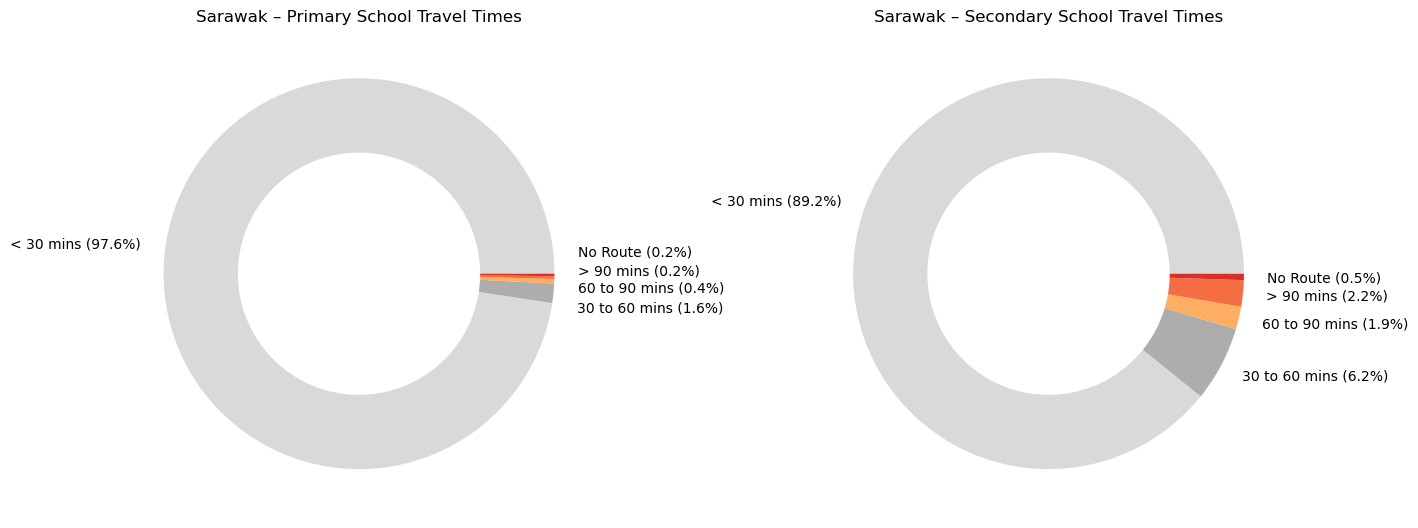

In [72]:
# --- Colour scheme (balanced & colour-blind friendly) ---
colour_map = {
    "< 30 mins":    "#d9d9d9",   # light neutral grey
    "30 to 60 mins":"#adadad",   # grey
    "60 to 90 mins":"#fdae61",   # warm orange
    "> 90 mins":    "#f46d43",   # strong orange-red
    "No Route":     "#d73027"    # deep red (critical)
}

# Ensure consistent category order
order = ["< 30 mins", "30 to 60 mins", "60 to 90 mins", "> 90 mins", "No Route"]
merged_time_pt = merged_time_pt.reindex(order)

# Extract percentage dictionaries
primary_modes = merged_time_pt["primary_pct"].to_dict()
secondary_modes = merged_time_pt["secondary_pct"].to_dict()

# -------------------------
# Create figure
# -------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

def adjust_labels(ax, indices, dx=0.0, dy=0.05):
    for i, txt in enumerate(ax.texts):
        if i in indices:
            x, y = txt.get_position()
            txt.set_position((x + dx, y + dy))

# --- Left donut (Primary) ---
ax[0].pie(
    primary_modes.values(),
    labels=[f"{k} ({v:.1f}%)" for k, v in primary_modes.items()],
    colors=[colour_map[k] for k in primary_modes.keys()],
    wedgeprops={'width': 0.38},
    labeldistance=1.12,
    pctdistance=0.50,
    textprops={'fontsize': 10}
)

# Move the top two labels upward
adjust_labels(ax[0], indices=[0,1], dy=-0.06)
adjust_labels(ax[0], indices=[0,2], dy=-0.03)
adjust_labels(ax[0], indices=[0,3], dy=0.04)
adjust_labels(ax[0], indices=[0,4], dy=0.12)

ax[0].set_title("Sarawak – Primary School Travel Times")


# --- Right donut (Secondary) ---
ax[1].pie(
    secondary_modes.values(),
    labels=[f"{k} ({v:.1f}%)" for k, v in secondary_modes.items()],
    colors=[colour_map[k] for k in secondary_modes.keys()],
    wedgeprops={'width': 0.38},
    labeldistance=1.12,
    pctdistance=0.50,
    textprops={'fontsize': 10}
)

ax[1].set_title("Sarawak – Secondary School Travel Times")

plt.tight_layout()
plt.show()

Interactive map for travel time grouped by categories

In [73]:
# Set tolerance

# Simplify geometry
tolerance = 0.00001  # ~1 metre, adjust if needed

# Primary
primary_pop_routes_gdf = gpd.GeoDataFrame(
    primary_pop_routes_gdf,
    geometry="geometry",
    crs="EPSG:4326"
)

primary_pop_routes_gdf["geometry"] = (
    primary_pop_routes_gdf.geometry.simplify(tolerance, preserve_topology=True)
)

# Secondary
secondary_pop_routes_gdf = gpd.GeoDataFrame(
    secondary_pop_routes_gdf,
    geometry="geometry",
    crs="EPSG:4326"
)

secondary_pop_routes_gdf["geometry"] = (
    secondary_pop_routes_gdf.geometry.simplify(tolerance, preserve_topology=True)
)

In [74]:
# PRIMARY SCHOOL

# -----------------------------
# 0. Define output folders
# -----------------------------

base_output_folder = output_folder_maps   # your original output folder
assets_folder = os.path.join(base_output_folder, "assets")
os.makedirs(assets_folder, exist_ok=True)

# HTML output file
output_path = os.path.join(
    base_output_folder,
    "swk_travel_time_category_primary_interactive_map.html"
)

# -----------------------------
# 1. Create gdfs for layers
# -----------------------------

students = "primary_school_students"
route_gdf = primary_pop_routes_gdf.rename(columns={"Travel Time":"time_category"})

# Define helper function
def create_layer_gdfs(category):
    gdf = route_gdf[route_gdf["time_category"]==category]
    gdf_route = gpd.GeoDataFrame(gdf.copy(), geometry="geometry", crs="EPSG:4326")
    gdf_pop = gpd.GeoDataFrame(
        gdf[["pop_id",students,"pop_x","pop_y","school_id","school_name","travel_mode","time_min","dist_km"]], 
        geometry=gpd.points_from_xy(gdf["pop_x"], gdf["pop_y"]), crs="EPSG:4326")
    
    return gdf_route, gdf_pop

gdf_route_0, gdf_pop_0 = create_layer_gdfs("< 30 mins")
gdf_route_30, gdf_pop_30 = create_layer_gdfs("30 to 60 mins")
gdf_route_60, gdf_pop_60 = create_layer_gdfs("60 to 90 mins")
gdf_route_90, gdf_pop_90 = create_layer_gdfs("> 90 mins")
gdf_route_no_route, gdf_pop_no_route = create_layer_gdfs("No Route")

# -----------------------------
# 2. Build colors for the combined routes
# -----------------------------

travel_mode_dict = {
    "car":  "#000000eb",   # black
    "foot": "#6200ffeb",   # purple
    "boat": "#00318DFF"    # blue
}

# define helper function
def apply_route_colors(gdf_route):
   gdf_route["colour"] = (
        gdf_route["travel_mode"]
        .map(travel_mode_dict)
        .astype("object")   
    )
   
   gdf_route = gpd.GeoDataFrame(gdf_route.copy(), geometry="geometry", crs="EPSG:4326")
   
   return gdf_route

# Apply
gdf_route_0 = apply_route_colors(gdf_route_0)
gdf_route_30 = apply_route_colors(gdf_route_30)
gdf_route_60 = apply_route_colors(gdf_route_60)
gdf_route_90 = apply_route_colors(gdf_route_90)

# -----------------------------
# 3. Build the interactive map
# -----------------------------

x = (route_gdf["pop_x"].max() + route_gdf["pop_x"].min()) / 2
y = (route_gdf["pop_y"].max() + route_gdf["pop_y"].min()) / 2

m = leafmap.Map(height="600px", center=[x, y], use_message_queue=True, style="street")

# Basemap
m.add_basemap("Esri.WorldImagery", before_id=m.first_symbol_layer_id, visible=False)
m.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri.WorldImagery (Basemap)",
    attribution="Esri World Imagery",
    visible=True
)

# -----------------------------
# 4. Create Population and Route Data Layers
# -----------------------------

# --- Travel Time category ---

# < 30 mins
m.add_gdf(
    gdf=gdf_pop_0,
    name="< 30 mins (population)",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#000000"},
    visible=True
)

m.add_gdf(
    gdf=gdf_route_0,
    name="< 30 mins (route)",
    layer_type="line",
    paint={"line-color": ["get", "colour"]},
    visible=False
)

# 30-60 mins
m.add_gdf(
    gdf=gdf_pop_30,
    name="30 to 60 mins (population)",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#adadad"},
    visible=True
)

m.add_gdf(
    gdf=gdf_route_30,
    name="30 to 60 mins (route)",
    layer_type="line",
    paint={"line-color": ["get", "colour"]},
    visible=False
)

# 60-90 mins
m.add_gdf(
    gdf=gdf_pop_60,
    name="60 to 90 mins (population)",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#fdae61"},
    visible=True
)

m.add_gdf(
    gdf=gdf_route_60,
    name="60 to 90 mins (route)",
    layer_type="line",
    paint={"line-color": ["get", "colour"]},
    visible=False
)

# > 90 mins
m.add_gdf(
    gdf=gdf_pop_90,
    name="> 90 mins (population)",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#f46d43"},
    visible=True
)

m.add_gdf(
    gdf=gdf_route_90,
    name="> 90 mins (route)",
    layer_type="line",
    paint={"line-color": ["get", "colour"]},
    visible=False
)

# No Route
m.add_gdf(
    gdf=gdf_pop_no_route,
    name="No Routes",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#d73027"},
    visible=True
)


# -----------------------------
# 5. Adminstrative Boundaries
# -----------------------------

# Adminstrative boundaries
m.add_gdf(
    gdf=swk_districts_gdf,
    name="District Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=True
)

m.add_gdf(
    gdf=swk_parlimen_gdf,
    name="Parlimen Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

m.add_gdf(
    gdf=swk_dun_gdf,
    name="DUN Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)


# -----------------------------
# 6. Add school layers
# -----------------------------

# -- Primary Schools ---
image_pri = "Interactive Maps/assets/icons/college_blue.png"

primary_geojson = json.loads(primary_school_gdf.to_json())
source_pri = {"type": "geojson", "data": primary_geojson}

layer_pri = {
    "id": "Primary Schools",
    "type": "symbol",
    "source": "point_pri",
    "layout": {
        "icon-image": "pri_school",
        "icon-size": 0.08}
}

m.add_image("pri_school", image_pri)
m.add_source("point_pri", source_pri)
m.add_layer(layer_pri)
m.add_popup("Primary Schools")

# -----------------------------
# 7. Add legend
# -----------------------------

colour_map = {
    "< 30 mins":    "#000000",   # light neutral grey
    "30 to 60 mins":"#adadad",   # grey
    "60 to 90 mins":"#fdae61",   # warm orange
    "> 90 mins":    "#f46d43",   # strong orange-red
    "No Route":     "#d73027"    # deep red (critical)
}

m.add_legend(
    title = "Travel Time",
    legend_dict = colour_map,
    position = "bottom-right"
)

# Legend for travel mode
travel_mode_dict = {
    "car":  "#000000eb",   # black
    "foot": "#6200ffeb",   # purple
    "boat": "#00318DFF"    # blue
}

m.add_legend(
    title = "Travel Mode",
    legend_dict = travel_mode_dict,
    position = "bottom-right"
)

# -----------------------------
# 8. Add map title / sources
# -----------------------------

m.add_text(
    "Primary School Travel Time",
    position="top-left",
    font_size=12
)

# -----------------------------
# 9. Layer control
# -----------------------------

m.add_layer_control(
    layer_ids=[
        "< 30 mins (population)",
        "< 30 mins (route)",
        "30 to 60 mins (population)",
        "30 to 60 mins (route)",
        "60 to 90 mins (population)",
        "60 to 90 mins (route)",
        "> 90 mins (population)",
        "> 90 mins (route)",
        "Primary Schools",
        "District Boundaries",
        "Parlimen Boundaries",
        "DUN Boundaries",
        "Esri.WorldImagery (Basemap)"
    ],
    position="top-left"
)

# -----------------------------
# 10. Export HTML
# -----------------------------

m.to_html(
    output=output_path,
    title="Primary School Travel Time",
    overwrite=True
)

m

Html(children=[<leafmap.maplibregl.Map object at 0x000002988D23B6D0>, Card(children=[Btn(children=[Icon(childr…

In [75]:
# SECONDARY SCHOOL

# -----------------------------
# 0. Define output folders
# -----------------------------

base_output_folder = output_folder_maps   # your original output folder
assets_folder = os.path.join(base_output_folder, "assets")
os.makedirs(assets_folder, exist_ok=True)

# HTML output file
output_path = os.path.join(
    base_output_folder,
    "swk_travel_time_category_secondary_interactive_map.html"
)

# -----------------------------
# 1. Create gdfs for layers
# -----------------------------

students = "secondary_school_students"
route_gdf = secondary_pop_routes_gdf.rename(columns={"Travel Time":"time_category"})

# Define helper function
def create_layer_gdfs(category):
    gdf = route_gdf[route_gdf["time_category"]==category]
    gdf_route = gpd.GeoDataFrame(gdf.copy(), geometry="geometry", crs="EPSG:4326")
    gdf_pop = gpd.GeoDataFrame(
        gdf[["pop_id",students,"pop_x","pop_y","school_id","school_name","travel_mode","time_min","dist_km"]], 
        geometry=gpd.points_from_xy(gdf["pop_x"], gdf["pop_y"]), crs="EPSG:4326")
    
    return gdf_route, gdf_pop

gdf_route_0, gdf_pop_0 = create_layer_gdfs("< 30 mins")
gdf_route_30, gdf_pop_30 = create_layer_gdfs("30 to 60 mins")
gdf_route_60, gdf_pop_60 = create_layer_gdfs("60 to 90 mins")
gdf_route_90, gdf_pop_90 = create_layer_gdfs("> 90 mins")
gdf_route_no_route, gdf_pop_no_route = create_layer_gdfs("No Route")

# -----------------------------
# 2. Build colors for the combined routes
# -----------------------------

travel_mode_dict = {
    "car":  "#000000eb",   # black
    "foot": "#6200ffeb",   # purple
    "boat": "#00318DFF"    # blue
}

# define helper function
def apply_route_colors(gdf_route):
   gdf_route["colour"] = (
        gdf_route["travel_mode"]
        .map(travel_mode_dict)
        .astype("object")   
    )
   
   gdf_route = gpd.GeoDataFrame(gdf_route.copy(), geometry="geometry", crs="EPSG:4326")
   
   return gdf_route

# Apply
gdf_route_0 = apply_route_colors(gdf_route_0)
gdf_route_30 = apply_route_colors(gdf_route_30)
gdf_route_60 = apply_route_colors(gdf_route_60)
gdf_route_90 = apply_route_colors(gdf_route_90)

# -----------------------------
# 3. Build the interactive map
# -----------------------------

x = (route_gdf["pop_x"].max() + route_gdf["pop_x"].min()) / 2
y = (route_gdf["pop_y"].max() + route_gdf["pop_y"].min()) / 2

m = leafmap.Map(height="600px", center=[x, y], use_message_queue=True, style="street")

# Basemap
m.add_basemap("Esri.WorldImagery", before_id=m.first_symbol_layer_id, visible=False)
m.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri.WorldImagery (Basemap)",
    attribution="Esri World Imagery",
    visible=True
)

# -----------------------------
# 4. Create Population and Route Data Layers
# -----------------------------

# --- Travel Time category ---

# < 30 mins
m.add_gdf(
    gdf=gdf_pop_0,
    name="< 30 mins (population)",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#000000"},
    visible=True
)

m.add_gdf(
    gdf=gdf_route_0,
    name="< 30 mins (route)",
    layer_type="line",
    paint={"line-color": ["get", "colour"]},
    visible=False
)

# 30-60 mins
m.add_gdf(
    gdf=gdf_pop_30,
    name="30 to 60 mins (population)",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#adadad"},
    visible=True
)

m.add_gdf(
    gdf=gdf_route_30,
    name="30 to 60 mins (route)",
    layer_type="line",
    paint={"line-color": ["get", "colour"]},
    visible=False
)

# 60-90 mins
m.add_gdf(
    gdf=gdf_pop_60,
    name="60 to 90 mins (population)",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#fdae61"},
    visible=True
)

m.add_gdf(
    gdf=gdf_route_60,
    name="60 to 90 mins (route)",
    layer_type="line",
    paint={"line-color": ["get", "colour"]},
    visible=False
)

# > 90 mins
m.add_gdf(
    gdf=gdf_pop_90,
    name="> 90 mins (population)",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#f46d43"},
    visible=True
)

m.add_gdf(
    gdf=gdf_route_90,
    name="> 90 mins (route)",
    layer_type="line",
    paint={"line-color": ["get", "colour"]},
    visible=False
)

# No Route
m.add_gdf(
    gdf=gdf_pop_no_route,
    name="No Routes",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#d73027"},
    visible=True
)


# -----------------------------
# 5. Adminstrative Boundaries
# -----------------------------

# Adminstrative boundaries
m.add_gdf(
    gdf=swk_districts_gdf,
    name="District Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=True
)

m.add_gdf(
    gdf=swk_parlimen_gdf,
    name="Parlimen Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

m.add_gdf(
    gdf=swk_dun_gdf,
    name="DUN Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)


# -----------------------------
# 6. Add school layers
# -----------------------------

# -- Secondary Schools ---
image_sec = "Interactive Maps/assets/icons/college_orange.png"

secondary_geojson = json.loads(secondary_school_gdf.to_json())
source_sec = {"type": "geojson", "data": secondary_geojson}

layer_sec = {
    "id": "Secondary Schools",
    "type": "symbol",
    "source": "point_sec",
    "layout": {
        "icon-image": "sec_school",
        "icon-size": 0.08}
}

m.add_image("sec_school", image_sec)
m.add_source("point_sec", source_sec)
m.add_layer(layer_sec)
m.add_popup("Secondary Schools")

# -----------------------------
# 7. Add legend
# -----------------------------

colour_map = {
    "< 30 mins":    "#000000",   # light neutral grey
    "30 to 60 mins":"#adadad",   # grey
    "60 to 90 mins":"#fdae61",   # warm orange
    "> 90 mins":    "#f46d43",   # strong orange-red
    "No Route":     "#d73027"    # deep red (critical)
}

m.add_legend(
    title = "Travel Time",
    legend_dict = colour_map,
    position = "bottom-right"
)

# Legend for travel mode
travel_mode_dict = {
    "car":  "#000000eb",   # black
    "foot": "#6200ffeb",   # purple
    "boat": "#00318DFF"    # blue
}

m.add_legend(
    title = "Travel Mode",
    legend_dict = travel_mode_dict,
    position = "bottom-right"
)

# -----------------------------
# 8. Add map title / sources
# -----------------------------

m.add_text(
    "Secondary School Travel Time",
    position="top-left",
    font_size=12
)

# -----------------------------
# 9. Layer control
# -----------------------------

m.add_layer_control(
    layer_ids=[
        "< 30 mins (population)",
        "< 30 mins (route)",
        "30 to 60 mins (population)",
        "30 to 60 mins (route)",
        "60 to 90 mins (population)",
        "60 to 90 mins (route)",
        "> 90 mins (population)",
        "> 90 mins (route)",
        "Secondary Schools",
        "District Boundaries",
        "Parlimen Boundaries",
        "DUN Boundaries",
        "Esri.WorldImagery (Basemap)"
    ],
    position="top-left"
)

# -----------------------------
# 10. Export HTML
# -----------------------------

m.to_html(
    output=output_path,
    title="Secondary School Travel Time",
    overwrite=True
)

m

Html(children=[<leafmap.maplibregl.Map object at 0x0000029877D35600>, Card(children=[Btn(children=[Icon(childr…

Static plot for secondary schools

In [76]:
# --- Split into two dataframes ---
gdf = route_gdf.copy()

under_60_gdf = gdf[gdf["time_min"] < 60]
over_60_gdf  = gdf[(gdf["time_min"] >= 60) | (gdf["time_min"].isna())]

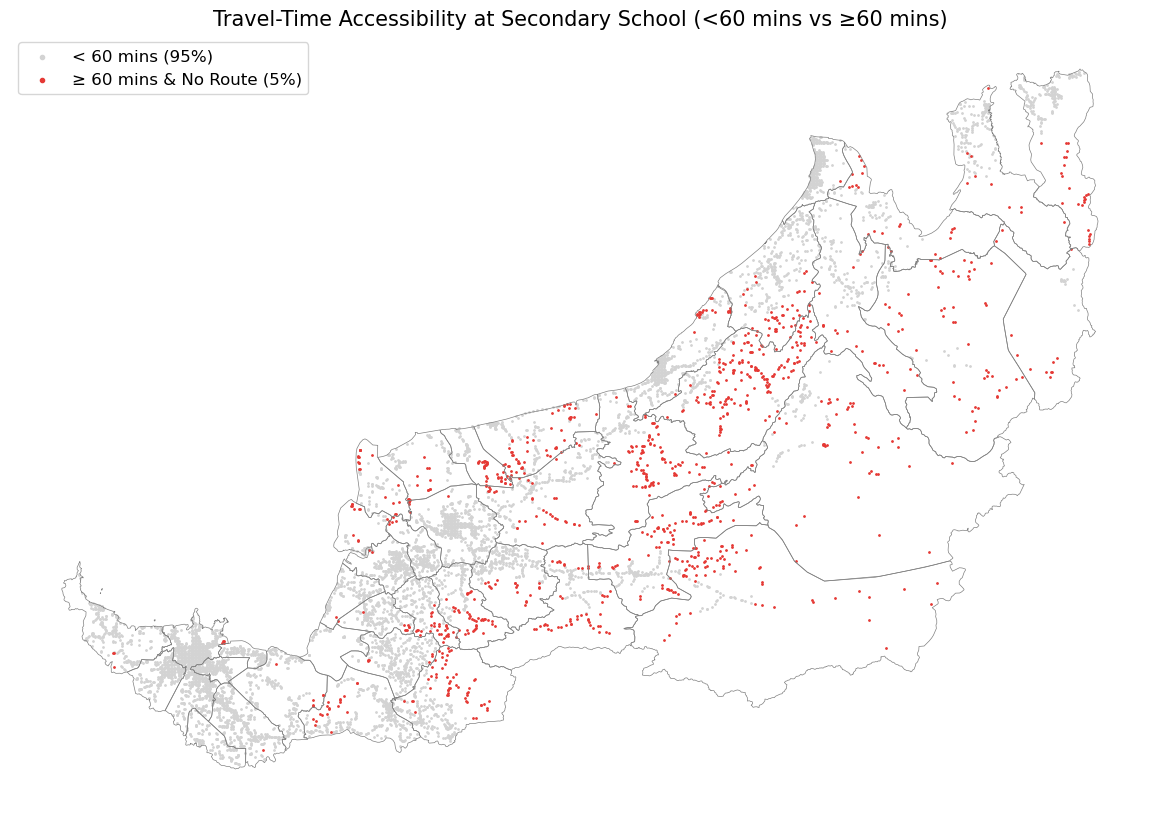

In [77]:
# Create static plot of the total population distribution
plt.figure(figsize=(16, 10))

ax = plt.gca() 

# Scatter plot
ax.scatter(under_60_gdf["pop_x"], under_60_gdf["pop_y"], s=1, color="lightgrey", label="< 60 mins (95%)")
ax.scatter(over_60_gdf["pop_x"], over_60_gdf["pop_y"], s=1, color="#E53935", label="≥ 60 mins & No Route (5%)")

# Add district boundaries
swk_districts_gdf.boundary.plot(ax=ax, edgecolor='grey', linewidth=0.5)

plt.title("Travel-Time Accessibility at Secondary School (<60 mins vs ≥60 mins)", fontsize=15)

plt.legend(
    loc="best",
    markerscale=3,
    frameon=True,
    fontsize=12
)

plt.axis("off")
plt.show()
